# ANN / MLP Modeling — Prediksi Risiko Dropout Mahasiswa

Notebook ini dipakai untuk:
1. membaca data hasil preprocessing,
2. melatih **Artificial Neural Network (ANN)** dengan `MLPClassifier`,
3. mengevaluasi model,
4. menyimpan artefak model dan metrik.

> Asumsi:
> - file hasil preprocessing sudah ada di `/kaggle/working/data/processed/`
> - target biner adalah kolom `dropout_risk`


In [4]:
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

## 1. Siapkan folder output

In [5]:
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/data/processed', exist_ok=True)

print('Folder output siap.')

Folder output siap.


## 2. Load data processed

In [6]:
train_path = '/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv'
test_path  = '/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
display(train_df.head())

Train shape: (3539, 38)
Test shape : (885, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout_risk
0,1,1,1,9147,1,1,130.0,1,38,37,...,5,5,1,12.000000,0,7.6,2.6,0.32,Dropout,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,6,10,4,11.500000,0,7.6,2.6,0.32,Dropout,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,6,10,5,13.125000,0,10.8,1.4,1.74,Dropout,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,6,12,6,13.833333,0,8.9,1.4,3.51,Graduate,0


## 3. Pisahkan fitur dan target

In [7]:
TARGET_COL = 'dropout_risk'

drop_cols = [TARGET_COL]
if 'Target' in train_df.columns:
    drop_cols.append('Target')

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[TARGET_COL]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Distribusi y_train:')
print(y_train.value_counts())

X_train: (3539, 36)
X_test : (885, 36)
Distribusi y_train:
dropout_risk
0    2402
1    1137
Name: count, dtype: int64


## 4. Buat pipeline preprocessing + ANN (MLPClassifier)

In [8]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)

ann_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

ann_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening '
                                                   'attendance\t',
                                                   'Previous qualification',
                                                   'Previous qualification '
                                                   '(grade)',
                                                   'Nacionality',
                                                   "Mother's qualification...
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curricular units 1st sem '
                                                   '(without evaluations)',
                                                   'Curricular units 2nd sem '
                                                   '(credited)',
                                                   'Curricular units 2nd sem '
                                                   '(enrolled)',
                                                   'Curricular units 2nd sem '
                                                   '(evaluations)', ...])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## 5. Training model

In [9]:
ann_pipeline.fit(X_train, y_train)
print('Training ANN selesai.')

Training ANN selesai.


## 6. Prediksi & evaluasi

In [10]:
y_pred = ann_pipeline.predict(X_test)
y_proba = ann_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    'model_name': 'ANN (MLPClassifier)',
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'f1_score': float(f1_score(y_test, y_pred)),
    'roc_auc': float(roc_auc_score(y_test, y_proba))
}

metrics

{'model_name': 'ANN (MLPClassifier)',
 'accuracy': 0.8395480225988701,
 'precision': 0.7649253731343284,
 'recall': 0.721830985915493,
 'f1_score': 0.7427536231884058,
 'roc_auc': 0.8804984649996486}

## 7. Classification report & confusion matrix

In [11]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       601
           1       0.76      0.72      0.74       284

    accuracy                           0.84       885
   macro avg       0.82      0.81      0.81       885
weighted avg       0.84      0.84      0.84       885



array([[538,  63],
       [ 79, 205]])

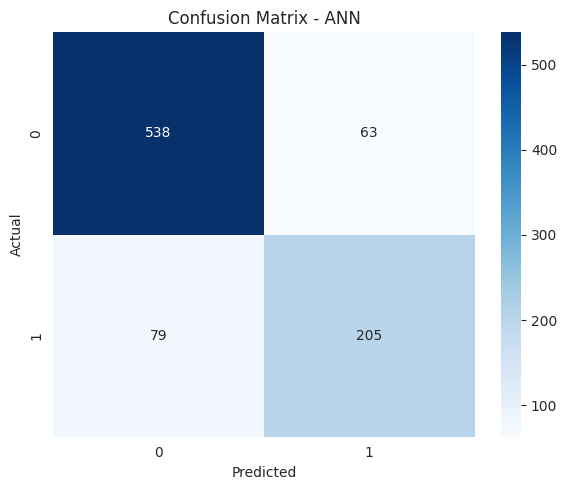

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/confusion_matrix_ann.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. ROC Curve

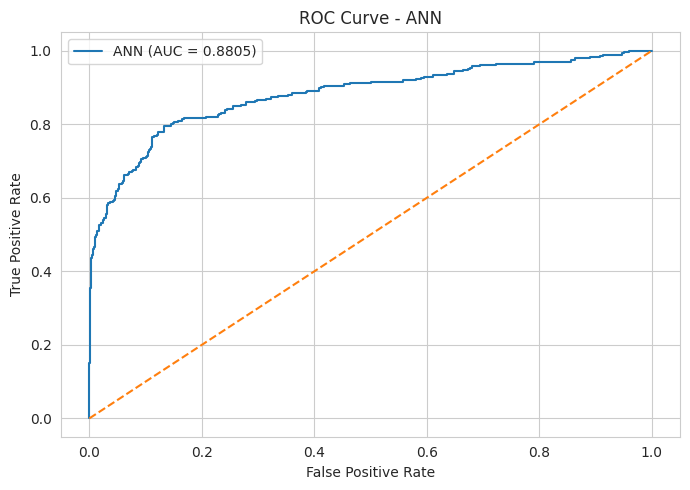

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ANN (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ANN')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/figures/roc_curve_ann.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Analisis bobot ANN

In [14]:
model = ann_pipeline.named_steps['model']

print('Jumlah layer bobot:', len(model.coefs_))
for i, w in enumerate(model.coefs_):
    print(f'Layer {i+1} shape: {w.shape}')

Jumlah layer bobot: 3
Layer 1 shape: (36, 64)
Layer 2 shape: (64, 32)
Layer 3 shape: (32, 1)


Karena ANN/MLP tidak punya `feature_importances_` seperti Random Forest, 
kita bisa melihat **pengaruh awal fitur** dari bobot layer input → hidden layer pertama.
Ini bukan interpretasi sesempurna tree-based model, tapi cukup untuk eksplorasi.

In [15]:
first_layer_weights = model.coefs_[0]   # shape: (n_features, n_hidden_units)
feature_importance_proxy = np.mean(np.abs(first_layer_weights), axis=1)

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance_proxy': feature_importance_proxy
}).sort_values(by='importance_proxy', ascending=False)

display(feat_imp.head(20))

,feature,importance_proxy
6,Previous qualification (grade),0.249647
33,Unemployment rate,0.248361
1,Application mode,0.242413
12,Admission grade,0.229257
9,Father's qualification,0.228633
15,Debtor,0.226059
35,GDP,0.225979
32,Curricular units 2nd sem (without evaluations),0.225029
16,Tuition fees up to date,0.224042
30,Curricular units 2nd sem (approved),0.222576


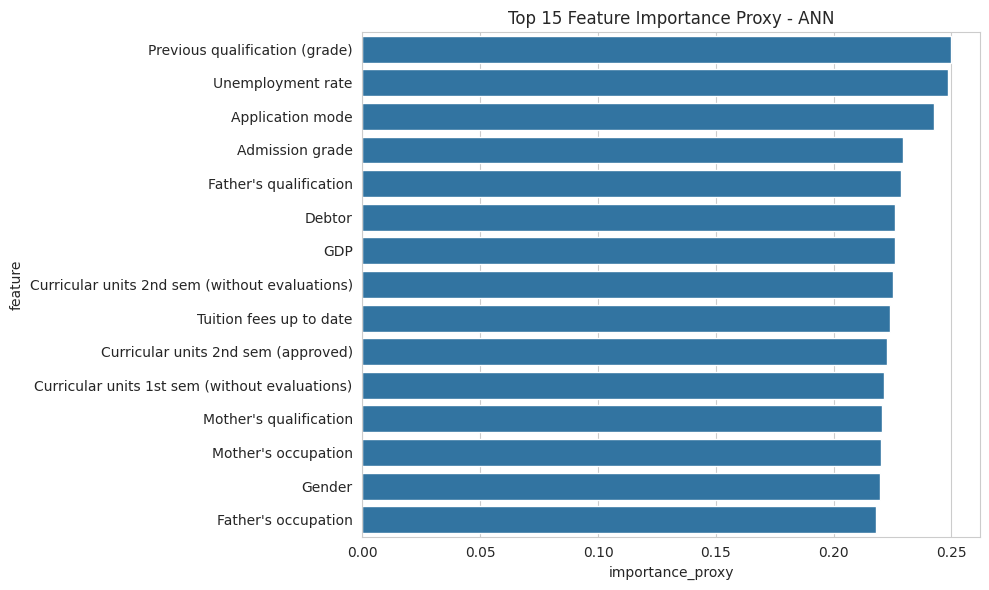

In [16]:
top_feat = feat_imp.head(15).copy()

plt.figure(figsize=(10,6))
sns.barplot(data=top_feat, x='importance_proxy', y='feature')
plt.title('Top 15 Feature Importance Proxy - ANN')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/feature_importance_ann.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Simpan model, preprocessor, dan metrics

In [17]:
joblib.dump(ann_pipeline, '/kaggle/working/models/ann_pipeline.pkl')
joblib.dump(ann_pipeline.named_steps['preprocessor'], '/kaggle/working/models/preprocessor_ann.pkl')

metrics_to_save = metrics.copy()
metrics_to_save['confusion_matrix'] = cm.tolist()
metrics_to_save['classification_report'] = classification_report(y_test, y_pred, output_dict=True)

with open('/kaggle/working/models/model_metrics_ann.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=4)

print('File berhasil disimpan:')
print('- /kaggle/working/models/ann_pipeline.pkl')
print('- /kaggle/working/models/preprocessor_ann.pkl')
print('- /kaggle/working/models/model_metrics_ann.json')

File berhasil disimpan:
- /kaggle/working/models/ann_pipeline.pkl
- /kaggle/working/models/preprocessor_ann.pkl
- /kaggle/working/models/model_metrics_ann.json


## 11. Ringkasan hasil

In [18]:
print('=== HASIL ANN ===')
for k, v in metrics.items():
    if k != 'model_name':
        print(f'{k}: {v:.4f}')
    else:
        print(f'{k}: {v}')

=== HASIL ANN ===
model_name: ANN (MLPClassifier)
accuracy: 0.8395
precision: 0.7649
recall: 0.7218
f1_score: 0.7428
roc_auc: 0.8805
